# 05b - So sanh Tracking: ByteTrack vs BoT-SORT vs OC-SORT vs Deep OC-SORT vs FastTracker vs TrackTrack

**3 thay doi so voi ban truoc:**

1. **Chay tren GPU** (thay vi CPU) - truyen tuong minh `device=0` vao `model.track()`,
   khong de ultralytics tu quyet dinh. Neu may khong co GPU, cell kiem tra o duoi se
   canh bao ro va tu dong roi ve CPU thay vi loi thang.
2. **Detector nang tu `yolov8n` len `yolov8s`** - lan chay CPU truoc voi `yolov8n` chi
   bat duoc ~23% ground truth (18581 box that, chi match ~4200) du da ha `conf=0.15`.
   Day la gioi han nang luc cua ban `nano`, khong phai loi nguong loc - nang model de
   co nen tang cong bang hon truoc khi so sanh 6 tracker.
3. **Them phan do FPS** (Buoc 3b) - do THOI GIAN THUC ca vong lap detector+tracker cho
   tung tracker (khong chi dua vao `r.speed`, vi so do KHONG tinh chi phi rieng cua
   thuat toan tracking nhu ReID trong Deep OC-SORT/TrackTrack).

**Thiet ke thi nghiem khong doi:** co dinh detector cho ca 6 tracker (`yolov8s`,
chay tren GPU), chi doi thuat toan tracking, de so sanh cong bang.

In [3]:
%pip install opencv-python numpy pandas matplotlib

  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/21/f0/9fa6e85cb10c8eb36a0222d27e50fe381b86ce49a55446bf39f491727564/opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/65/66/53f31807a48a750f9d748da273bc3fcedd12b27ff1f3e373bfec55ef2dc0/numpy-2.5.1-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/70/b5/d2d3e9ae73362ba4229651b0ee1455cf78073a1ce585f6ff693782ce263e/pandas-3.0.5-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/88/89/56649bbaa2fd12e20f3be03dbcc135b0c8676d88bac17977599e3eb442a0/matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     -------------------- ------------------- 41.0/80.3 kB 1.9 MB/s eta 0:00:01
  

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys

print("Python đang chạy notebook:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python đang chạy notebook:
d:\Code\Face recognition security system\.venv_gpu\Scripts\python.exe

Python version:
3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]


In [2]:
# ===== CELL 1: Thiet lap duong dan =====
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = r'D:\Code\Face recognition security system'
AI_DIR = os.path.join(BASE_DIR, 'ai')
BENCHMARK_DIR = os.path.join(AI_DIR, 'dataset', 'benchmarks')
RESULTS_DIR = os.path.join(AI_DIR, 'models', 'tracker_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

MOT_SEQUENCE = 'MOT17-02-FRCNN'
mot_seq_dir = os.path.join(BENCHMARK_DIR, MOT_SEQUENCE)
img_dir = os.path.join(mot_seq_dir, 'img1')
gt_path = os.path.join(mot_seq_dir, 'gt', 'gt.txt')

assert os.path.exists(img_dir) and os.path.exists(gt_path), (
    f"Chua thay du lieu MOT17 tai {mot_seq_dir}"
)
print("Da tim thay du lieu MOT17 tai:", mot_seq_dir)


Da tim thay du lieu MOT17 tai: D:\Code\Face recognition security system\ai\dataset\benchmarks\MOT17-02-FRCNN


In [4]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("PyTorch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]
PyTorch: 2.7.1+cu118
PyTorch CUDA: 11.8
CUDA available: True
CUDA device count: 1
GPU: NVIDIA GeForce GTX 1650


In [5]:
# ===== CELL 2: Cai dat / nang cap thu vien + kiem tra GPU =====
!pip install -U -q ultralytics motmetrics

import ultralytics
print("ultralytics version:", ultralytics.__version__)

if not hasattr(np, 'asfarray'):
    np.asfarray = lambda a, dtype=float: np.asarray(a, dtype=dtype)

import torch

CUDA_OK = torch.cuda.is_available()
TRACK_DEVICE = 0 if CUDA_OK else 'cpu'  # 0 = GPU dau tien, dung tuong minh thay vi de auto

print(f"\nTorch version: {torch.__version__}")
print(f"CUDA available: {CUDA_OK}")
if CUDA_OK:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("KHONG thay GPU - se tu dong roi ve CPU, FPS do duoc se thap hon nhieu so voi GPU.")

print(f"\n=> Se chay tren device={TRACK_DEVICE} ({'GPU' if CUDA_OK else 'CPU'})")


ultralytics version: 8.4.108

Torch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce GTX 1650
VRAM: 4.3 GB

=> Se chay tren device=0 (GPU)



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Buoc 1 - Dung anh MOT17 thanh video tam + doc ground truth

In [7]:
# ===== CELL 3: Dung sequence anh thanh 1 video tam =====

def build_video_from_image_sequence(image_dir, output_video_path, fps=25):
    frame_files = sorted(f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png')))
    assert frame_files, f"Khong tim thay anh nao trong {image_dir}"

    first_img = cv2.imread(os.path.join(image_dir, frame_files[0]))
    h, w = first_img.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))
    for fname in frame_files:
        writer.write(cv2.imread(os.path.join(image_dir, fname)))
    writer.release()
    return len(frame_files), w, h


temp_video_path = os.path.join(RESULTS_DIR, f'{MOT_SEQUENCE}_temp_trackingcmp.mp4')
n_frames, seq_w, seq_h = build_video_from_image_sequence(img_dir, temp_video_path, fps=25)
print(f"Da dung {n_frames} anh ({seq_w}x{seq_h}) thanh video tam: {temp_video_path}")


Da dung 600 anh (1920x1080) thanh video tam: D:\Code\Face recognition security system\ai\models\tracker_results\MOT17-02-FRCNN_temp_trackingcmp.mp4


In [8]:
# ===== CELL 4: Doc ground truth (chi giu pedestrian, conf==1) =====

gt_cols = ['frame', 'id', 'x', 'y', 'w', 'h', 'conf', 'cls', 'vis']
gt_df = pd.read_csv(gt_path, header=None, names=gt_cols)
gt_df = gt_df[(gt_df['conf'] == 1) & (gt_df['cls'] == 1)]

print(f"Ground truth (sau loc): {len(gt_df)} box qua {gt_df['frame'].nunique()} frame")


Ground truth (sau loc): 18581 box qua 600 frame


## Buoc 2 - Chay tung tracker tren GPU (cung 1 detector) + tinh MOTA/IDF1 + do FPS

`run_tracker()` truyen tuong minh `device=TRACK_DEVICE` vao `model.track()` de bat
buoc chay GPU (neu co), va tra ve them `fps`/`elapsed_sec` do bang dong ho thuc
(wall-clock) BAO QUANH TOAN BO vong lap detector+tracker - phan anh dung chi phi
THEM VAO cua tung thuat toan tracking (Deep OC-SORT/TrackTrack co ReID/association
phuc tap hon se lo ro qua so nay).

In [9]:
# ===== CELL MOI A: Uoc luong ground truth VUNG MAT tu ground truth NGUOI cua MOT17 =====
# CANH BAO: day la XAP XI, khong phai nhan that - MOT17 khong co ground truth khuon mat.
# Chi dung de so sanh TUONG DOI giua 6 tracker khi cung chay tren dau vao SCRFD,
# KHONG so sanh tuyet doi voi ket qua YOLOv8 (nguoi) o cell 6 phia tren.

FACE_HEIGHT_RATIO = 0.20  # mat uoc tinh chiem ~20% chieu cao tu dinh dau nguoi
FACE_WIDTH_RATIO = 0.45   # va ~45% chieu rong, can giua


def estimate_face_gt(person_gt_df: pd.DataFrame) -> pd.DataFrame:
    face_rows = []
    for _, row in person_gt_df.iterrows():
        face_w = row['w'] * FACE_WIDTH_RATIO
        face_h = row['h'] * FACE_HEIGHT_RATIO
        face_x = row['x'] + (row['w'] - face_w) / 2
        face_y = row['y']  # tinh tu dinh dau nguoi
        face_rows.append([row['frame'], row['id'], face_x, face_y, face_w, face_h])
    return pd.DataFrame(face_rows, columns=['frame', 'id', 'x', 'y', 'w', 'h'])


gt_face_df = estimate_face_gt(gt_df)
print(f"Da uoc luong {len(gt_face_df)} vung mat tu ground truth nguoi (XAP XI, khong phai nhan that)")

Da uoc luong 18581 vung mat tu ground truth nguoi (XAP XI, khong phai nhan that)


In [10]:
# ===== CELL 5: Ham chay 1 tracker cu the tren GPU, tra ve ket qua + FPS =====
from ultralytics import YOLO

PERSON_CLASS_ID = 0
DETECTOR_MODEL = 'yolov8s.pt'  # NANG tu yolov8n - xem ly do o markdown dau notebook


def run_tracker(tracker_config: str, video_path: str, conf: float = 0.1,
                 model_name: str = DETECTOR_MODEL, device=TRACK_DEVICE):
    """Chay detector CO DINH (model_name) tren device (GPU neu co) voi 1 tracker
    config cu the. Tra ve (track_df, fps, elapsed_sec)."""
    model = YOLO(model_name)

    rows = []
    frame_count = 0

    start_time = time.time()
    results_gen = model.track(
        source=video_path, persist=True, tracker=tracker_config,
        classes=[PERSON_CLASS_ID], conf=conf, device=device,
        stream=True, verbose=False,
    )

    for frame_idx, r in enumerate(results_gen, start=1):  # MOT dung frame bat dau tu 1
        frame_count += 1
        boxes = r.boxes
        if boxes is not None and len(boxes) > 0 and boxes.id is not None:
            xyxy = boxes.xyxy.cpu().numpy()
            track_ids = boxes.id.cpu().numpy().astype(int)
            for (x1, y1, x2, y2), tid in zip(xyxy, track_ids):
                rows.append([frame_idx, int(tid), x1, y1, x2 - x1, y2 - y1])

    if CUDA_OK:
        torch.cuda.synchronize()  # dam bao dem het thoi gian GPU thuc su xu ly xong
    elapsed = time.time() - start_time
    fps = frame_count / elapsed if elapsed > 0 else 0.0

    track_df = pd.DataFrame(rows, columns=['frame', 'id', 'x', 'y', 'w', 'h'])
    return track_df, fps, elapsed


print(f"Da dinh nghia run_tracker() - detector co dinh: {DETECTOR_MODEL}, device: {TRACK_DEVICE}")


Da dinh nghia run_tracker() - detector co dinh: yolov8s.pt, device: 0


In [18]:
# ===== CELL MOI C: Ham chay tracker tren dau vao SCRFD (thay the run_tracker cho phan nay) =====
# LUU Y QUAN TRONG: day la API NOI BO cua ultralytics (khong chinh thuc ho tro dung
# ngoai model.track()) - dua tren cach cong dong da xac nhan hoat dong (xem giai thich
# truoc do). Rui ro loi cao hon code dung model.track() binh thuong - da them try/except
# rieng tung tracker o Cell D de 1 tracker loi khong lam sap ca 6 tracker con lai.

import types
from ultralytics.utils import YAML, IterableSimpleNamespace
from ultralytics.utils.checks import check_yaml
from ultralytics.engine.results import Boxes

try:
    from ultralytics.trackers import TRACKER_MAP
except ImportError:
    from ultralytics.trackers.track import TRACKER_MAP


def create_tracker(tracker_config, device):
    """Nap tracker theo ten config (giong het co che noi bo cua model.track())."""
    tracker_yaml_path = check_yaml(tracker_config)
    cfg = IterableSimpleNamespace(**YAML.load(tracker_yaml_path))
    cfg.device = device

    if cfg.tracker_type not in TRACKER_MAP:
        raise ValueError(f"Tracker '{cfg.tracker_type}' khong co trong TRACKER_MAP: {sorted(TRACKER_MAP)}")

    tracker_cls = TRACKER_MAP[cfg.tracker_type]
    return tracker_cls(cfg)


def detect_faces_scrfd(frame):
    """Chay SCRFD tren 1 frame anh, tra ve cac box (xyxy) va confidence score."""
    faces = face_app.get(frame)
    if not faces:
        return np.empty((0, 6))
    dets = []
    for f in faces:
        x1, y1, x2, y2 = f.bbox
        dets.append([x1, y1, x2, y2, f.det_score, 0])  # cls=0 (mat)
    return np.array(dets)


def run_tracker_scrfd(tracker_config, video_path):
    """Ban thay the run_tracker() nhung dung SCRFD (khuon mat) thay YOLOv8 (nguoi).
    Tra ve (track_df, fps, elapsed_sec) - cung dinh dang de dung lai duoc ham danh gia
    motmetrics phia duoi, chi doi ground truth so sanh tu gt_df sang gt_face_df."""
    tracker = create_tracker(tracker_config, device=TRACK_DEVICE)

    cap = cv2.VideoCapture(video_path)
    rows = []
    frame_count = 0

    start_time = time.time()
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1

        dets = detect_faces_scrfd(frame)
        fake_results = Boxes(dets, orig_shape=frame.shape[:2])
        tracks = tracker.update(fake_results, img=frame)

        for t in tracks:
            x1, y1, x2, y2, track_id = t[0], t[1], t[2], t[3], int(t[4])
            rows.append([frame_count, track_id, x1, y1, x2 - x1, y2 - y1])

    cap.release()
    if CUDA_OK:
        torch.cuda.synchronize()
    elapsed = time.time() - start_time
    fps = frame_count / elapsed if elapsed > 0 else 0.0

    track_df = pd.DataFrame(rows, columns=['frame', 'id', 'x', 'y', 'w', 'h'])
    return track_df, fps, elapsed


print("Da dinh nghia create_tracker(), detect_faces_scrfd(), run_tracker_scrfd()")

Da dinh nghia create_tracker(), detect_faces_scrfd(), run_tracker_scrfd()


In [12]:
# ===== CELL MOI B: Khoi tao SCRFD detector (insightface) =====
!pip install -q insightface onnxruntime-gpu

from insightface.app import FaceAnalysis

FACE_DET_THRESH = 0.3
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if CUDA_OK else ['CPUExecutionProvider']

face_app = FaceAnalysis(name='buffalo_l', providers=providers)
face_app.prepare(ctx_id=0 if CUDA_OK else -1, det_size=(640, 640), det_thresh=FACE_DET_THRESH)

print(f"Da khoi tao SCRFD (buffalo_l), providers={providers}")


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSI VN/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSI VN/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSI VN/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSI VN/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSI VN/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112]

In [20]:
# ===== CELL MOI D: Chay ca 6 tracker tren SCRFD, tinh MOTA/IDF1 =====
import traceback
import motmetrics as mm
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
TRACKER_CONFIGS = {
    'ByteTrack':     'bytetrack.yaml',
    'BoT-SORT':      'botsort.yaml',
    'OC-SORT':       'ocsort.yaml',
    'Deep OC-SORT':  'deepocsort.yaml',
    'FastTracker':   'fasttrack.yaml',
    'TrackTrack':    'tracktrack.yaml',
}

comparison_rows_scrfd = []
per_tracker_track_df_scrfd = {}

for tracker_name, tracker_config in TRACKER_CONFIGS.items():
    print(f"\n=== Dang chay {tracker_name} ({tracker_config}) tren SCRFD ===")
    try:
        track_df, fps, elapsed = run_tracker_scrfd(tracker_config, temp_video_path)
    except Exception as e:
        print(f"BO QUA {tracker_name} - loi khi chay:")
        traceback.print_exc()   # <-- IN DAY DU traceback thay vi chi str(e)
        continue

    per_tracker_track_df_scrfd[tracker_name] = track_df
    print(f"Thu thap duoc {len(track_df)} detection qua {track_df['frame'].nunique()} frame "
          f"trong {elapsed:.1f}s ({fps:.1f} FPS)")

    acc = mm.MOTAccumulator(auto_id=False)
    all_frames = sorted(set(gt_face_df['frame'].unique().tolist()) | set(track_df['frame'].unique().tolist()))

    for frame in all_frames:
        gt_frame = gt_face_df[gt_face_df['frame'] == frame]
        tr_frame = track_df[track_df['frame'] == frame]

        gt_ids = gt_frame['id'].tolist()
        tr_ids = tr_frame['id'].tolist()
        gt_boxes = gt_frame[['x', 'y', 'w', 'h']].values
        tr_boxes = tr_frame[['x', 'y', 'w', 'h']].values

        dists = mm.distances.iou_matrix(gt_boxes, tr_boxes, max_iou=0.5)
        acc.update(gt_ids, tr_ids, dists, frameid=frame)

    mh = mm.metrics.create()
    summary = mh.compute(
        acc,
        metrics=['num_frames', 'mota', 'motp', 'idf1', 'num_switches',
                 'num_false_positives', 'num_misses', 'num_matches'],
        name=tracker_name,
    )

    row = summary.iloc[0].to_dict()
    row['tracker'] = tracker_name
    row['fps'] = round(fps, 2)
    row['elapsed_sec'] = round(elapsed, 1)
    comparison_rows_scrfd.append(row)

    print(mm.io.render_summary(summary, formatters=mh.formatters, namemap=mm.io.motchallenge_metric_names))

# ----- Kiem tra truoc khi tao DataFrame, tranh KeyError kho hieu -----
if not comparison_rows_scrfd:
    print("\n!!! CA 6 TRACKER DEU LOI - xem traceback tung cai o tren de biet nguyen nhan that.")
else:
    comparison_df_scrfd = pd.DataFrame(comparison_rows_scrfd).set_index('tracker')
    comparison_csv_path = os.path.join(RESULTS_DIR, 'tracking_comparison_scrfd.csv')
    comparison_df_scrfd.to_csv(comparison_csv_path)
    print(f"\nDa luu bang so sanh (SCRFD, ground truth XAP XI): {comparison_csv_path}")

comparison_df_scrfd if comparison_rows_scrfd else None


=== Dang chay ByteTrack (bytetrack.yaml) tren SCRFD ===
Thu thap duoc 2113 detection qua 600 frame trong 835.1s (0.7 FPS)
          num_frames   MOTA  MOTP IDF1 IDs   FP    FN num_matches
ByteTrack        600 -11.0% 0.402 0.3%   1 2074 18542          38

=== Dang chay BoT-SORT (botsort.yaml) tren SCRFD ===
Thu thap duoc 2123 detection qua 600 frame trong 782.9s (0.8 FPS)
         num_frames   MOTA  MOTP IDF1 IDs   FP    FN num_matches
BoT-SORT        600 -11.0% 0.399 0.3%   1 2084 18542          38

=== Dang chay OC-SORT (ocsort.yaml) tren SCRFD ===
Thu thap duoc 2098 detection qua 597 frame trong 828.3s (0.7 FPS)
        num_frames   MOTA  MOTP IDF1 IDs   FP    FN num_matches
OC-SORT        600 -10.9% 0.401 0.4%   1 2059 18542          38

=== Dang chay Deep OC-SORT (deepocsort.yaml) tren SCRFD ===
Thu thap duoc 2098 detection qua 597 frame trong 792.4s (0.8 FPS)
             num_frames   MOTA  MOTP IDF1 IDs   FP    FN num_matches
Deep OC-SORT        600 -10.9% 0.401 0.4%   1 2059 18

,num_frames,mota,motp,idf1,num_switches,num_false_positives,num_misses,num_matches,fps,elapsed_sec
tracker,,,,,,,,,,
ByteTrack,600.0,-0.109574,0.401628,0.003479,1.0,2074.0,18542.0,38.0,0.72,835.1
BoT-SORT,600.0,-0.110112,0.399019,0.003381,1.0,2084.0,18542.0,38.0,0.77,782.9
OC-SORT,600.0,-0.108767,0.401014,0.003675,1.0,2059.0,18542.0,38.0,0.72,828.3
Deep OC-SORT,600.0,-0.108767,0.401014,0.003675,1.0,2059.0,18542.0,38.0,0.76,792.4
FastTracker,600.0,-0.109359,0.401351,0.003480,1.0,2070.0,18542.0,38.0,0.77,778.0
TrackTrack,600.0,-0.042678,0.388006,0.002676,1.0,820.0,18553.0,27.0,0.04,13563.1


In [21]:
# ===== CELL 6: Chay ca 6 tracker, tinh MOTA/IDF1 va FPS =====
import motmetrics as mm

TRACKER_CONFIGS = {
    'ByteTrack':     'bytetrack.yaml',
    'BoT-SORT':      'botsort.yaml',
    'OC-SORT':       'ocsort.yaml',
    'Deep OC-SORT':  'deepocsort.yaml',
    'FastTracker':   'fasttrack.yaml',
    'TrackTrack':    'tracktrack.yaml',
}

comparison_rows = []
per_tracker_track_df = {}

for tracker_name, tracker_config in TRACKER_CONFIGS.items():
    print(f"\n=== Dang chay {tracker_name} ({tracker_config}) ===")
    try:
        track_df, fps, elapsed = run_tracker(tracker_config, temp_video_path, conf=0.1)
    except Exception as e:
        print(f"BO QUA {tracker_name} - loi khi chay: {e}")
        continue

    per_tracker_track_df[tracker_name] = track_df
    print(f"Thu thap duoc {len(track_df)} detection qua {track_df['frame'].nunique()} frame "
          f"trong {elapsed:.1f}s ({fps:.1f} FPS)")

    acc = mm.MOTAccumulator(auto_id=False)
    all_frames = sorted(set(gt_df['frame'].unique().tolist()) | set(track_df['frame'].unique().tolist()))

    for frame in all_frames:
        gt_frame = gt_df[gt_df['frame'] == frame]
        tr_frame = track_df[track_df['frame'] == frame]

        gt_ids = gt_frame['id'].tolist()
        tr_ids = tr_frame['id'].tolist()
        gt_boxes = gt_frame[['x', 'y', 'w', 'h']].values
        tr_boxes = tr_frame[['x', 'y', 'w', 'h']].values

        dists = mm.distances.iou_matrix(gt_boxes, tr_boxes, max_iou=0.5)
        acc.update(gt_ids, tr_ids, dists, frameid=frame)

    mh = mm.metrics.create()
    summary = mh.compute(
        acc,
        metrics=['num_frames', 'mota', 'motp', 'idf1', 'num_switches',
                 'num_false_positives', 'num_misses', 'num_matches'],
        name=tracker_name,
    )

    row = summary.iloc[0].to_dict()
    row['tracker'] = tracker_name
    row['fps'] = round(fps, 2)
    row['elapsed_sec'] = round(elapsed, 1)
    comparison_rows.append(row)

    print(mm.io.render_summary(summary, formatters=mh.formatters, namemap=mm.io.motchallenge_metric_names))

comparison_df = pd.DataFrame(comparison_rows).set_index('tracker')
comparison_csv_path = os.path.join(RESULTS_DIR, 'tracking_comparison_full.csv')
comparison_df.to_csv(comparison_csv_path)

print(f"\nDa luu bang so sanh: {comparison_csv_path}")
comparison_df



=== Dang chay ByteTrack (bytetrack.yaml) ===
Thu thap duoc 4357 detection qua 384 frame trong 62.4s (6.2 FPS)
          num_frames  MOTA  MOTP  IDF1 IDs  FP    FN num_matches
ByteTrack        600 14.1% 0.226 25.9%  33 848 15072        3476

=== Dang chay BoT-SORT (botsort.yaml) ===
Thu thap duoc 4409 detection qua 384 frame trong 34.3s (11.2 FPS)
         num_frames  MOTA  MOTP  IDF1 IDs  FP    FN num_matches
BoT-SORT        600 14.4% 0.215 26.1%  34 849 15021        3526

=== Dang chay OC-SORT (ocsort.yaml) ===
Thu thap duoc 3682 detection qua 384 frame trong 22.0s (17.5 FPS)
        num_frames  MOTA  MOTP  IDF1 IDs  FP    FN num_matches
OC-SORT        600 13.7% 0.210 24.1%  41 544 15443        3097

=== Dang chay Deep OC-SORT (deepocsort.yaml) ===
Thu thap duoc 3443 detection qua 384 frame trong 16.2s (23.7 FPS)
             num_frames  MOTA  MOTP  IDF1 IDs  FP    FN num_matches
Deep OC-SORT        600 13.3% 0.204 23.1%  41 468 15606        2934

=== Dang chay FastTracker (fasttrack

,num_frames,mota,motp,idf1,num_switches,num_false_positives,num_misses,num_matches,fps,elapsed_sec
tracker,,,,,,,,,,
ByteTrack,600.0,0.141435,0.225564,0.259046,33.0,848.0,15072.0,3476.0,6.15,62.4
BoT-SORT,600.0,0.144072,0.215214,0.261070,34.0,849.0,15021.0,3526.0,11.21,34.3
OC-SORT,600.0,0.137398,0.210312,0.241387,41.0,544.0,15443.0,3097.0,17.45,22.0
Deep OC-SORT,600.0,0.132716,0.204176,0.230567,41.0,468.0,15606.0,2934.0,23.69,16.2
FastTracker,600.0,0.142134,0.228973,0.257576,41.0,934.0,14965.0,3575.0,25.67,15.0
TrackTrack,600.0,0.102470,0.135785,0.183225,3.0,33.0,16641.0,1937.0,12.96,29.6


## Buoc 3 - Xac dinh tracker "tot nhat" bang diem tong hop (do chinh xac)

MOTA/IDF1 do o thang % (cao hon = tot hon), `num_switches` la so lan (thap hon = tot
hon) - chuan hoa truoc khi cong lai. **Diem nay CHUA tinh FPS** - xem Buoc 3b de doi
chieu ca 2 chieu accuracy va toc do truoc khi chon cuoi cung.

In [22]:
# ===== CELL 7: Tinh diem tong hop (accuracy) va xep hang =====

ranking_df = comparison_df.copy()

ranking_df['mota_norm'] = (ranking_df['mota'] - ranking_df['mota'].min()) / (
    ranking_df['mota'].max() - ranking_df['mota'].min() + 1e-9)
ranking_df['idf1_norm'] = (ranking_df['idf1'] - ranking_df['idf1'].min()) / (
    ranking_df['idf1'].max() - ranking_df['idf1'].min() + 1e-9)
ranking_df['switch_norm'] = 1 - (ranking_df['num_switches'] - ranking_df['num_switches'].min()) / (
    ranking_df['num_switches'].max() - ranking_df['num_switches'].min() + 1e-9)

ranking_df['composite_score'] = (
    0.35 * ranking_df['mota_norm'] +
    0.45 * ranking_df['idf1_norm'] +
    0.20 * ranking_df['switch_norm']
)

ranking_df = ranking_df.sort_values('composite_score', ascending=False)
best_tracker_accuracy = ranking_df.index[0]

print("XEP HANG THEO DO CHINH XAC (composite_score cao nhat = tot nhat):")
print(ranking_df[['mota', 'idf1', 'num_switches', 'fps', 'composite_score']].round(3))
print(f"\n>>> TOT NHAT VE DO CHINH XAC: {best_tracker_accuracy} <<<")

ranking_csv_path = os.path.join(RESULTS_DIR, 'tracking_ranking.csv')
ranking_df.to_csv(ranking_csv_path)
print(f"Da luu bang xep hang: {ranking_csv_path}")


XEP HANG THEO DO CHINH XAC (composite_score cao nhat = tot nhat):
               mota   idf1  num_switches    fps  composite_score
tracker                                                         
BoT-SORT      0.144  0.261          34.0  11.21            0.837
ByteTrack     0.141  0.259          33.0   6.15            0.808
FastTracker   0.142  0.258          41.0  25.67            0.764
OC-SORT       0.137  0.241          41.0  17.45            0.630
Deep OC-SORT  0.133  0.231          41.0  23.69            0.528
TrackTrack    0.102  0.183           3.0  12.96            0.200

>>> TOT NHAT VE DO CHINH XAC: BoT-SORT <<<
Da luu bang xep hang: D:\Code\Face recognition security system\ai\models\tracker_results\tracking_ranking.csv


## Buoc 3b - Doi chieu Accuracy vs FPS (khong the chon chi dua vao 1 chieu)

He thong an ninh can chay **real-time** - 1 tracker chinh xac nhat nhung qua cham
se khong dung duoc trong `pipeline_runner.py` thuc te. Ve bieu do scatter de nhin
truc quan tradeoff nay, tuong tu cach Notebook 05a so sanh detector.

NameError: name 'comparison_df' is not defined

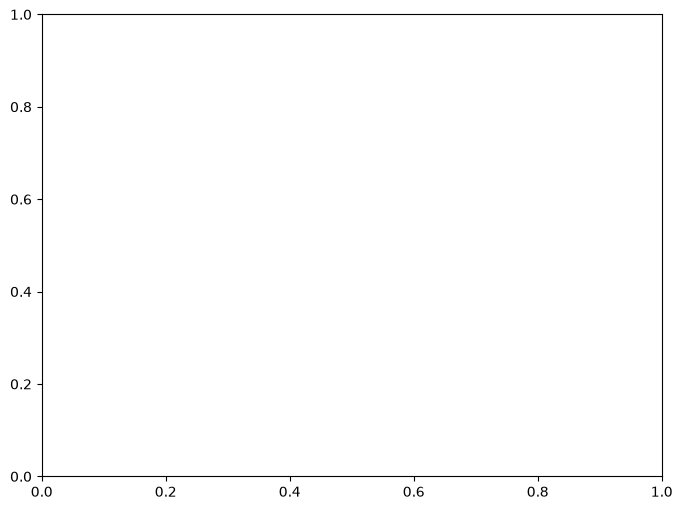

In [3]:
# ===== CELL 8: Bieu do Accuracy vs FPS (scatter) =====

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(comparison_df['fps'], comparison_df['idf1'] * 100, s=120, c='steelblue')

for tracker_name in comparison_df.index:
    ax.annotate(
        tracker_name,
        (comparison_df.loc[tracker_name, 'fps'], comparison_df.loc[tracker_name, 'idf1'] * 100),
        textcoords="offset points", xytext=(6, 6), fontsize=9,
    )

device_label = 'GPU' if CUDA_OK else 'CPU'
ax.set_xlabel(f'FPS ({device_label})')
ax.set_ylabel('IDF1 (%)')
ax.set_title('Tradeoff: Toc do vs Do chinh xac giu danh tinh (IDF1)')
ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'tracking_accuracy_vs_speed.png')
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Da luu bieu do: {plot_path}")


## Buoc 4 - Bieu do so sanh chi tiet 6 tracker (MOTA/IDF1/Switch/FPS)

In [ ]:
# ===== CELL 9: Ve bieu do so sanh 6 tracker =====

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

trackers = comparison_df.index.tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(trackers)))

axes[0, 0].bar(trackers, comparison_df['mota'] * 100, color=colors)
axes[0, 0].set_title('MOTA (%)')
axes[0, 0].set_ylabel('%')
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(trackers, comparison_df['idf1'] * 100, color=colors)
axes[0, 1].set_title('IDF1 (%) - quan trong nhat cho he thong nay')
axes[0, 1].set_ylabel('%')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].bar(trackers, comparison_df['num_switches'], color=colors)
axes[1, 0].set_title('So lan ID Switch (thap hon = tot hon)')
axes[1, 0].set_ylabel('So lan')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].grid(axis='y', alpha=0.3)

device_label = 'GPU' if CUDA_OK else 'CPU'
axes[1, 1].bar(trackers, comparison_df['fps'], color=colors)
axes[1, 1].set_title(f'FPS ({device_label})')
axes[1, 1].set_ylabel('FPS')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'tracking_comparison_full.png')
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Da luu bieu do: {plot_path}")


## Ket luan - Doc ket qua theo dung thu tu uu tien

**Buoc 1 - Kiem tra xem viec nang detector (+ chay GPU) co giai quyet duoc goc re
khong:** so `num_matches`/`num_misses` moi voi lan chay `yolov8n` tren CPU truoc day.
Neu ty le match tang ro ret (vi du tu ~23% len >50-60% tong ground truth), xac nhan
dung chan doan - luc do so sanh giua 6 tracker moi thuc su dang tin. Neu van thap
tuong tu, can tiep tuc nang len `yolov8m` hoac xem xet lai `conf`.

**Buoc 2 - Neu do chinh xac da dang tin, doi chieu voi FPS (Buoc 3b):**
- Neu tracker co `composite_score` cao nhat (Buoc 3) **cung** co FPS chap nhan duoc
  (khong thua kem nhieu so voi ByteTrack) - chon thang do la hop ly, khong can
  danh doi gi ca.
- Neu tracker chinh xac nhat (thuong la Deep OC-SORT/TrackTrack, co ReID) cham
  hon **dang ke** - can tu hoi: he thong that co chay tren camera tinh trong nha
  khong? Neu co, huong dan chinh thuc cua Ultralytics noi ByteTrack von da phu
  hop cho truong hop nay, phan chenh lech accuracy nho co the khong dang danh
  doi lay toc do.

**Luu y quan trong ve FPS do duoc:** day la FPS cua **rieng detector+tracker**,
CHUA cong them thoi gian `insightface` (get_embedding) chay tren tung crop nguoi
trong `pipeline_runner.py` that - FPS end-to-end thuc te cua toan he thong se
THAP HON so nay, vi con phai cong them buoc nhan dien khuon mat nua. Neu chay
tren GPU, insightface (`onnxruntime`) cung can duoc chuyen sang ban GPU rieng
(`onnxruntime-gpu`) de FPS end-to-end phan anh dung tiem nang GPU - hien
`face_recognition_service.py` dang cau hinh `providers=['CPUExecutionProvider']`,
se can sua lai neu muon dung GPU cho ca phan nhan dien khuon mat.

Ghi lai tracker cuoi cung chon vao day sau khi doi chieu ca 2 chieu:
`___________________`